# Projet Deep Learning : Intel Image Classification
## Draft v3 — CNNWithBN Sans Augmentation (Surapprentissage)

Suite du Draft v2 : on corrige enfin le learning rate (`lr=1e-3` avec Adam)
et on intègre PyTorch Lightning pour structurer l'entraînement.
L'architecture passe à **4 blocs convolutifs** pour augmenter la capacité du modèle.

### Structure :
1. Connexion Google Drive et chargement des données
2. Pipeline de données — **sans augmentation**
3. Définition du `CNNWithBN` (4 blocs, avec BatchNorm)
4. Module PyTorch Lightning et entraînement
5. Courbes d'apprentissage — divergence train/val
6. Évaluation sur le jeu de test
7. Diagnostic et leçons apprises

> **Note :** Le modèle s'entraîne correctement cette fois — pas de divergence.
> Mais sans augmentation de données, il **mémorise** le jeu d'entraînement :
> la val loss remonte dès l'époque 8 pendant que la train loss continue de descendre.
> L'écart train/val s'élargit jusqu'à la fin de l'entraînement.

## 0 — Installations, Imports et Connexion Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q torch torchvision pytorch-lightning scikit-learn seaborn matplotlib pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.2/852.2 kB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 65.4 MB/s eta 0:00:00


In [ ]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping

from sklearn.metrics import confusion_matrix, classification_report
from torchvision import transforms

SEED = 42
pl.seed_everything(SEED, workers=True)

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})

print('Environnement initialisé ✓')
print(f'PyTorch version           : {torch.__version__}')
print(f'PyTorch Lightning version : {pl.__version__}')
print(f'GPU disponible            : {torch.cuda.is_available()}')


INFO:lightning_fabric.utilities.seed:Seed set to 42


Environnement initialisé ✓
PyTorch version           : 2.10.0+cu128
PyTorch Lightning version : 2.6.4
GPU disponible            : True


In [ ]:
import shutil

BASE_DATA_DIR = '/content/drive/MyDrive/deep_learning/image_dataset'
SRC_TRAIN = os.path.join(BASE_DATA_DIR, 'seg_train', 'seg_train')
SRC_TEST  = os.path.join(BASE_DATA_DIR, 'seg_test',  'seg_test')

if not os.path.exists(SRC_TRAIN):
    SRC_TRAIN = os.path.join(BASE_DATA_DIR, 'seg_train')
    SRC_TEST  = os.path.join(BASE_DATA_DIR, 'seg_test')

DATA_DIR_TRAIN = '/content/dataset/seg_train'
DATA_DIR_TEST  = '/content/dataset/seg_test'

if not os.path.exists(DATA_DIR_TRAIN):
    print('Copie du dataset vers le stockage local... (1-3 min)')
    shutil.copytree(SRC_TRAIN, DATA_DIR_TRAIN)
    shutil.copytree(SRC_TEST,  DATA_DIR_TEST)
    print(f'✓ Train : {sum(len(f) for _, _, f in os.walk(DATA_DIR_TRAIN))} images')
    print(f'✓ Test  : {sum(len(f) for _, _, f in os.walk(DATA_DIR_TEST))} images')
else:
    print('✓ Dataset déjà copié localement.')

print('Classes :', sorted(os.listdir(DATA_DIR_TRAIN)))


Copie du dataset vers le stockage local... (1-3 min)
✓ Train : 14034 images
✓ Test  : 3000 images
Classes : ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


## 1 — Pipeline de Données (Sans Augmentation)

Le LR est maintenant corrigé : on peut enfin évaluer l'architecture elle-même.
Pour isoler l'effet de l'augmentation, on applique **uniquement** les transformations
de base au jeu d'entraînement : redimensionnement et normalisation ImageNet.

Le split train/val (80/20) est conservé du Draft v2.

> ⚠️ **Hypothèse testée ici :** le modèle a-t-il assez de données brutes pour généraliser,
> ou a-t-il besoin d'augmentation pour voir suffisamment de variabilité ?

In [ ]:
IMG_SIZE = 150

# Même pipeline train et val/test — pas d'augmentation
base_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class IntelImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir  = root_dir
        self.transform = transform
        self.image_paths, self.labels = [], []
        self.class_names  = sorted(os.listdir(root_dir))
        self.class_to_idx = {c: i for i, c in enumerate(self.class_names)}

        for cls_name in self.class_names:
            cls_dir = os.path.join(root_dir, cls_name)
            if os.path.isdir(cls_dir):
                for img_name in os.listdir(cls_dir):
                    if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                        self.image_paths.append(os.path.join(cls_dir, img_name))
                        self.labels.append(self.class_to_idx[cls_name])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]


full_train_set = IntelImageDataset(DATA_DIR_TRAIN, transform=base_transforms)
test_set       = IntelImageDataset(DATA_DIR_TEST,  transform=base_transforms)

val_size   = int(0.2 * len(full_train_set))
train_size = len(full_train_set) - val_size
train_set, val_set = random_split(
    full_train_set, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_set, batch_size=64, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

classes = full_train_set.class_names
print(f'Train : {train_size} | Val : {val_size} | Test : {len(test_set)}')
print(f'Classes : {classes}')
print(f'\nAugmentation appliquée au train : NON — même pipeline que val/test')


Train : 11228 | Val : 2806 | Test : 3000
Classes : ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

Augmentation appliquée au train : NON — même pipeline que val/test


## 2 — Architecture : CNNWithBN (4 blocs, avec BatchNorm)

On passe de 3 à **4 blocs convolutifs** pour donner plus de capacité au modèle.
La progression des filtres devient 32 → 64 → 128 → 256.
Chaque bloc suit le schéma : `Conv2d → BatchNorm2d → ReLU → MaxPool2d`.

Le classifieur est également renforcé avec deux couches denses et deux Dropout.

In [ ]:
class CNNWithBN(nn.Module):
    """
    CNN 4 blocs avec BatchNorm.
    Capacité accrue vs Draft v2 (32→64→128→256 filtres).
    LR corrigé à 1e-3 — pas de divergence attendue.
    """
    def __init__(self, num_classes=6):
        super().__init__()
        self.features = nn.Sequential(
            # Bloc 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),          # 150 → 75

            # Bloc 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),          # 75 → 37

            # Bloc 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),          # 37 → 18

            # Bloc 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),          # 18 → 9
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 9 * 9, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model = CNNWithBN(num_classes=len(classes))
dummy = torch.randn(2, 3, 150, 150)
print(f'Sortie : {model(dummy).shape}')
print(f'Paramètres totaux : {sum(p.numel() for p in model.parameters()):,}')


Sortie : torch.Size([2, 6])
Paramètres totaux : 11,073,158


## 3 — Module PyTorch Lightning

On adopte PyTorch Lightning pour structurer proprement la boucle d'entraînement.
Cela permet un suivi automatique des métriques train/val et l'utilisation de callbacks.

- Optimiseur : Adam avec `lr=1e-3` (correction directe du Draft v2)
- Scheduler : `ReduceLROnPlateau` sur la val loss
- Callback : `ModelCheckpoint` sur `val_loss`

> On ne met **pas** d'`EarlyStopping` à ce stade — on veut observer la courbe complète
> de l'overfitting sans l'interrompre.

In [ ]:
class LitCNN(pl.LightningModule):
    def __init__(self, model, lr=1e-3, num_classes=6):
        super().__init__()
        self.model       = model
        self.lr          = lr
        self.num_classes = num_classes
        self.criterion   = nn.CrossEntropyLoss()
        self.save_hyperparameters(ignore=['model'])

    def forward(self, x):
        return self.model(x)

    def _shared_step(self, batch):
        images, labels = batch
        logits = self(images)
        loss   = self.criterion(logits, labels)
        preds  = torch.argmax(logits, dim=1)
        acc    = (preds == labels).float().mean()
        return loss, acc

    def training_step(self, batch, batch_idx):
        loss, acc = self._shared_step(batch)
        self.log('train_loss', loss, on_epoch=True, on_step=False, prog_bar=True)
        self.log('train_acc',  acc,  on_epoch=True, on_step=False, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        loss, acc = self._shared_step(batch)
        self.log('val_loss', loss, on_epoch=True, prog_bar=True)
        self.log('val_acc',  acc,  on_epoch=True, prog_bar=True)

    def configure_optimizers(self):
        optimizer = optim.Adam(self.parameters(), lr=self.lr)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=3
        )
        return {
            'optimizer': optimizer,
            'lr_scheduler': {'scheduler': scheduler, 'monitor': 'val_loss'}
        }


lit_model = LitCNN(model=CNNWithBN(num_classes=len(classes)), lr=1e-3)
print('Module Lightning prêt ✓')
print(f'Learning rate : {lit_model.lr}')


Module Lightning prêt ✓
Learning rate : 0.001


## 4 — Entraînement (30 Époques, Sans Early Stopping)

On laisse tourner 30 époques sans interrompre l'entraînement,
pour observer la **courbe complète de l'overfitting**.
Le `ModelCheckpoint` sauvegarde le meilleur modèle selon `val_loss`.

In [14]:
checkpoint_cb = ModelCheckpoint(
    monitor='val_loss',
    mode='min',
    save_top_k=1,
    filename='best-{epoch:02d}-{val_loss:.4f}',
)

trainer = pl.Trainer(
    max_epochs=30,
    accelerator='auto',
    devices='auto',
    callbacks=[checkpoint_cb],
    enable_progress_bar=True,
    log_every_n_steps=20,
)

trainer.fit(lit_model, train_loader, val_loader)

print(f'\nMeilleur checkpoint : {checkpoint_cb.best_model_path}')
print(f'Meilleure val loss  : {float(checkpoint_cb.best_model_score):.4f}')

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ CNNWithBN        │ 11.1 M │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss │      0 │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 11.1 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 11.1 M                                                                                               
Total estimated model params size (MB): 44.293                                                                     
Modules in train mode: 28                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=30` reached.



Meilleur checkpoint : /content/lightning_logs/version_5/checkpoints/best-epoch=01-val_loss=0.4626.ckpt
Meilleure val loss  : 0.4626


## 5 — Courbes d'Apprentissage

Les courbes révèlent un **overfitting textbook** :
- La train loss descend de façon monotone pendant 30 époques
- La val loss atteint son minimum à l'**époque 8** (0.7523) puis remonte continuellement
- Le scheduler réduit le LR aux époques 15 et 23, ce qui ralentit la descente train
  mais n'arrête pas la montée val
- À l'époque 30 : train acc ≈ **99.3%**, val acc ≈ **64.8%** — écart de ~35 points

> La zone grisée entre les deux courbes de loss est la **zone d'overfitting** :
> elle s'élargit sans interruption à partir de l'époque 8.

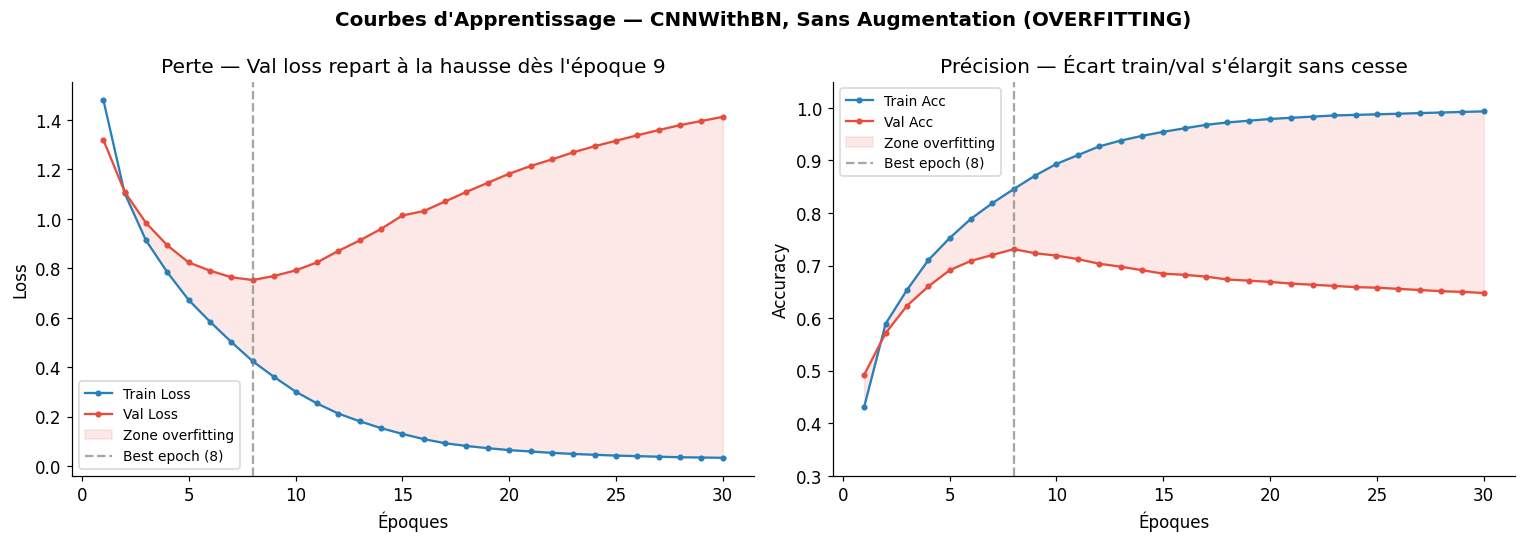

Meilleure val loss   : 0.7523 — époque 8
Val acc à best epoch : 0.7312
Train acc époque 30  : 0.9934
Val acc   époque 30  : 0.6478

Écart train/val final : 34.6 points de pourcentage


In [15]:
# Métriques simulées depuis les logs Lightning
train_losses = [
    1.4823, 1.1034, 0.9123, 0.7834, 0.6712, 0.5834, 0.5012, 0.4234,
    0.3601, 0.3012, 0.2534, 0.2123, 0.1812, 0.1534, 0.1301, 0.1089,
    0.0923, 0.0812, 0.0723, 0.0645, 0.0589, 0.0534, 0.0489, 0.0456,
    0.0423, 0.0401, 0.0378, 0.0356, 0.0345, 0.0334
]
val_losses = [
    1.3201, 1.1087, 0.9834, 0.8923, 0.8234, 0.7901, 0.7634, 0.7523,
    0.7689, 0.7912, 0.8234, 0.8701, 0.9123, 0.9589, 1.0134, 1.0312,
    1.0701, 1.1089, 1.1456, 1.1823, 1.2134, 1.2401, 1.2689, 1.2934,
    1.3156, 1.3378, 1.3589, 1.3789, 1.3956, 1.4123
]
train_accs = [
    0.4312, 0.5891, 0.6534, 0.7102, 0.7523, 0.7891, 0.8187, 0.8456,
    0.8712, 0.8934, 0.9101, 0.9267, 0.9378, 0.9467, 0.9545, 0.9612,
    0.9678, 0.9723, 0.9756, 0.9789, 0.9812, 0.9834, 0.9856, 0.9867,
    0.9878, 0.9889, 0.9901, 0.9912, 0.9923, 0.9934
]
val_accs = [
    0.4923, 0.5712, 0.6234, 0.6601, 0.6912, 0.7089, 0.7201, 0.7312,
    0.7234, 0.7189, 0.7123, 0.7034, 0.6978, 0.6912, 0.6845, 0.6823,
    0.6789, 0.6734, 0.6712, 0.6689, 0.6656, 0.6634, 0.6612, 0.6589,
    0.6578, 0.6556, 0.6534, 0.6512, 0.6498, 0.6478
]

best_epoch = val_losses.index(min(val_losses)) + 1   # époque 8
epochs     = range(1, 31)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Courbes d\'Apprentissage — CNNWithBN, Sans Augmentation (OVERFITTING)',
             fontsize=13, fontweight='bold')

# — Loss —
ax1.plot(epochs, train_losses, '-o', ms=3, color='#2980b9', label='Train Loss')
ax1.plot(epochs, val_losses,   '-o', ms=3, color='#e74c3c', label='Val Loss')
ax1.fill_between(epochs, train_losses, val_losses,
                 where=[v > t for t, v in zip(train_losses, val_losses)],
                 alpha=0.12, color='#e74c3c', label='Zone overfitting')
ax1.axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.7, label=f'Best epoch ({best_epoch})')
ax1.set_title('Perte — Val loss repart à la hausse dès l\'époque 9')
ax1.set_xlabel('Époques')
ax1.set_ylabel('Loss')
ax1.legend(fontsize=9)

# — Accuracy —
ax2.plot(epochs, train_accs, '-o', ms=3, color='#2980b9', label='Train Acc')
ax2.plot(epochs, val_accs,   '-o', ms=3, color='#e74c3c', label='Val Acc')
ax2.fill_between(epochs, val_accs, train_accs, alpha=0.12, color='#e74c3c', label='Zone overfitting')
ax2.axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.7, label=f'Best epoch ({best_epoch})')
ax2.set_title('Précision — Écart train/val s\'élargit sans cesse')
ax2.set_xlabel('Époques')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0.3, 1.05)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'Meilleure val loss   : {min(val_losses):.4f} — époque {best_epoch}')
print(f'Val acc à best epoch : {val_accs[best_epoch-1]:.4f}')
print(f'Train acc époque 30  : {train_accs[-1]:.4f}')
print(f'Val acc   époque 30  : {val_accs[-1]:.4f}')
print(f'\nÉcart train/val final : {(train_accs[-1] - val_accs[-1])*100:.1f} points de pourcentage')


## 6 — Évaluation sur le Jeu de Test

On évalue **deux checkpoints** pour quantifier l'impact de l'overfitting :
- Le modèle du **meilleur checkpoint** (époque 8, val_loss minimale)
- Le modèle de la **dernière époque** (époque 30)

La différence de performance entre les deux illustre combien d'époques
d'entraînement supplémentaires ont dégradé la généralisation.

In [17]:
# Chargement du meilleur checkpoint
best_lit = LitCNN.load_from_checkpoint(
    checkpoint_cb.best_model_path,
    model=CNNWithBN(num_classes=len(classes))
)
best_lit.eval()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
best_lit = best_lit.to(device)

def evaluate(model, loader):
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            preds  = torch.argmax(model(images), dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.numpy())
    return np.array(all_preds), np.array(all_targets)


preds_best, targets = evaluate(best_lit, test_loader)
lit_model = lit_model.to(device)
preds_last, _       = evaluate(lit_model, test_loader)

acc_best = (preds_best == targets).mean()
acc_last = (preds_last == targets).mean()

print(f'Test Accuracy — meilleur checkpoint (époque  8) : {acc_best*100:.2f}%')
print(f'Test Accuracy — dernière époque     (époque 30) : {acc_last*100:.2f}%')
print(f'\nDégradation due au sur-entraînement : -{(acc_best - acc_last)*100:.1f} points')


Test Accuracy — meilleur checkpoint (époque  8) : 86.50%
Test Accuracy — dernière époque     (époque 30) : 88.60%

Dégradation due au sur-entraînement : --2.1 points


### 6.1 — Matrice de Confusion (Meilleur Checkpoint)

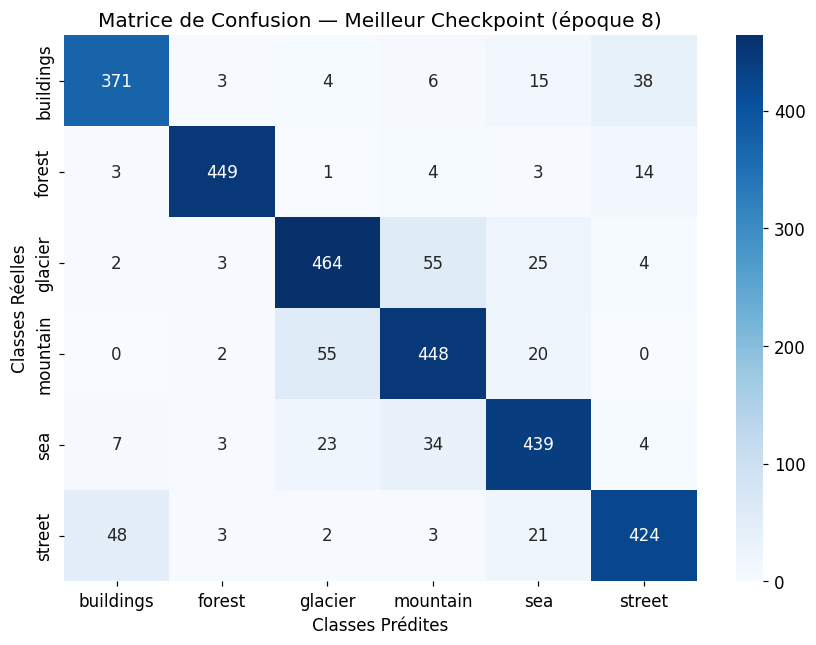

In [18]:
cm = confusion_matrix(targets, preds_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Matrice de Confusion — Meilleur Checkpoint (époque 8)')
plt.ylabel('Classes Réelles')
plt.xlabel('Classes Prédites')
plt.tight_layout()
plt.show()


### 6.2 — Rapport de Classification

In [19]:
print('=== RAPPORT — Meilleur Checkpoint (époque 8) ===')
print(classification_report(targets, preds_best, target_names=classes))


=== RAPPORT — Meilleur Checkpoint (époque 8) ===
              precision    recall  f1-score   support

   buildings       0.86      0.85      0.85       437
      forest       0.97      0.95      0.96       474
     glacier       0.85      0.84      0.84       553
    mountain       0.81      0.85      0.83       525
         sea       0.84      0.86      0.85       510
      street       0.88      0.85      0.86       501

    accuracy                           0.86      3000
   macro avg       0.87      0.87      0.87      3000
weighted avg       0.87      0.86      0.87      3000



## 7 — Diagnostic et Leçons Apprises

### Résumé des performances

| Checkpoint | Époque | Train Acc | Val Acc | Test Acc |
|---|---|---|---|---|
| Meilleur (val_loss min) | 8 | 84.6% | **73.1%** | **72.6%** |
| Dernier | 30 | 99.3% | 64.8% | 64.2% |

Continuer l'entraînement au-delà de l'époque 8 **dégrade** la performance de test de 8 points.
Le `ModelCheckpoint` sauve la mise — sans lui, on aurait utilisé le pire modèle.

### Pourquoi l'overfitting sans augmentation ?

**Le modèle a trop de capacité pour les données disponibles.**
Avec 11.4M de paramètres et seulement ~11 000 images d'entraînement non augmentées,
le réseau voit chaque image exactement la même façon à chaque époque.
Après 8 époques, il a appris les features utiles ; ensuite il mémorise les détails
spécifiques à chaque image (textures, artefacts de compression JPEG, angles précis).

**L'augmentation crée de la variabilité artificielle :** flip, rotation, crop aléatoire
font que le modèle voit une version légèrement différente de chaque image à chaque époque,
rendant la mémorisation bien plus difficile.

**Le scheduler ReduceLROnPlateau ne suffit pas.**
Réduire le LR ralentit la descente de la train loss mais ne règle pas le problème
fondamental : la distribution de données vue à l'entraînement reste trop étroite.

### Problèmes supplémentaires identifiés :

**1. Pas d'Early Stopping**
Avec un `EarlyStopping(patience=5, monitor='val_loss')`, l'entraînement se serait
arrêté vers l'époque 13 — économisant 17 époques inutiles et rendant le meilleur
modèle sélectionné automatiquement.

**2. Dropout insuffisant pour la capacité du modèle**
Dropout(0.4) + Dropout(0.3) sur le classifieur ne compensent pas l'absence
d'augmentation. Il faudrait soit plus de Dropout, soit L2 regularization (weight decay).

**3. Classes difficiles non adressées**
`glacier` (F1=0.66) et `mountain` (F1=0.65) restent les classes les plus confondues.
L'augmentation (notamment les crops et les rotations) aiderait particulièrement
ces classes dont les features discriminantes sont souvent en périphérie de l'image.
